<a href="https://colab.research.google.com/github/joaoalexandre14/ex9_avcad/blob/main/ex9_avcad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 8 Resolution - AVCAD





0. Data Preparation
Import the necessary libraries, load the EFIplus_medit.csv dataset, and select/standardize the quantitative variables for the sites in the Douro and Tejo basins.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset

df = pd.read_csv('EFIplus_medit.csv', delimiter=';')

# 2. Filter only for the Douro and Tejo basins
df_basins = df[df['Catchment_name'].isin(['Douro', 'Tejo'])]

# 3. Select quantitative environmental variables (example)
env_cols = ['Altitude', 'Actual_river_slope', 'Elevation_mean_catch',
            'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul']

# Remove rows with missing values (NaN) to avoid errors during distance calculations
df_quant = df_basins[env_cols].dropna()

# 4. Standardize the data (A crucial step before Cluster Analysis)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_quant),
                         columns=df_quant.columns,
                         index=df_quant.index)

1. Run agglomerative cluster analysis using different linkage methods
Calculation of the linkage matrices using the Ward, Complete, and Average methods.

In [4]:
# Calculate the linkage matrices
link_ward = linkage(df_scaled, method='ward')
link_complete = linkage(df_scaled, method='complete')
link_average = linkage(df_scaled, method='average')

print("Linkage matrices calculated successfully.")

Linkage matrices calculated successfully.


2. Plot a heatmap and a dendrogram by clustering the rows (sites) using average linkage
Visualizing the clustering of sites based on the similarity of their environmental conditions. The Y-axis labels (site names) were omitted to facilitate the global reading of the heatmap.

<Figure size 1200x1000 with 0 Axes>

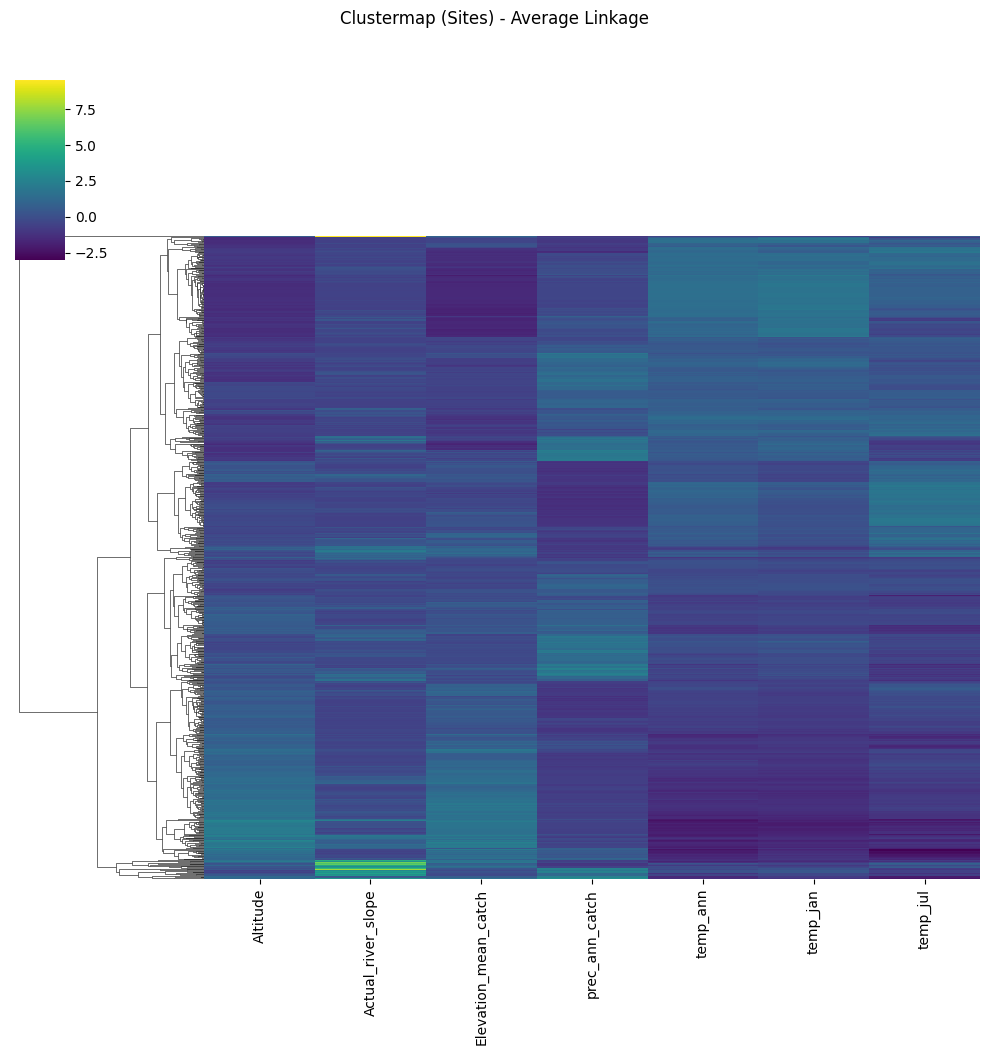

In [5]:
plt.figure(figsize=(12, 10))

# Create the Clustermap (clustering only the rows/sites)
sns.clustermap(df_scaled, method='average', metric='euclidean',
               figsize=(10, 10), cmap='viridis',
               col_cluster=False,
               yticklabels=False) # Hides site names to make the plot less dense

plt.suptitle('Clustermap (Sites) - Average Linkage', y=1.05)
plt.show()

3. Plot a dendrogram that clusters the environmental variables instead (columns) using average linkage
Clustering environmental variables to identify collinearities.

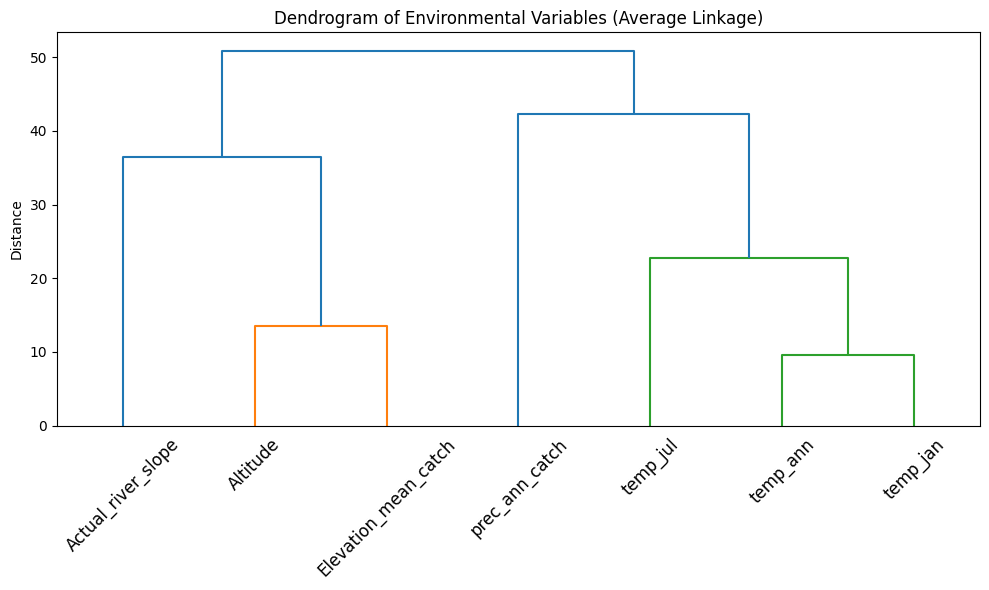

In [6]:
plt.figure(figsize=(10, 6))

# Transpose the matrix (.T) to group columns (variables) instead of rows
link_cols = linkage(df_scaled.T, method='average')

# Create the dendrogram
dendrogram(link_cols, labels=df_scaled.columns, leaf_rotation=45, leaf_font_size=12)
plt.title('Dendrogram of Environmental Variables (Average Linkage)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Discussion: Variable Selection for Regression Analysis
"Discuss how this would help to select variables for e.g. a regression-based analysis."

Clustering variables and visualizing them through a dendrogram is a highly valuable tool for predictor selection in regression analysis, especially for mitigating multicollinearity issues:

Identification of Redundant Variables: Variables that cluster together at a very short distance on the dendrogram (as often happens with temperature variables, e.g., temp_ann and temp_jul) show a high degree of correlation. This indicates that they are providing overlapping or redundant information regarding the environmental conditions of the sites.

Prevention of Model Instability: Including highly collinear variables in a regression model inflates the standard errors of the coefficients, rendering the model unstable and making it difficult to interpret the true weight/impact of each predictor.

Retention Strategy (Parsimony): Through the visual analysis of the dendrogram, we can establish a "cut-off" distance line and select only one representative variable per main cluster. This method allows us to simplify the model, avoid including noise, and ensure that we retain predictors representing distinct and independent environmental dynamics.